In [1]:
import pandas as pd
import numpy as np
import joblib
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir rutas (ajusta los nombres de archivo si es necesario)
export_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Models/'
test_data_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/test_topicos.csv'

# 3. Cargar el vectorizador y el modelo de Regresión Logística
print("Cargando modelo y vectorizador desde Google Drive...")
tfidf = joblib.load(export_path + 'tfidf_vectorizer.joblib')
lr_model = joblib.load(export_path + 'lr_model.joblib')

# 4. Cargar el dataset de testeo externo
print("Cargando dataset de test...")
df_test = pd.read_csv(test_data_path)
df_test['text_avanzado'] = df_test['text_avanzado'].fillna('')

# 5. Transformar los textos de test con el vectorizador ya entrenado
# (Recordar: SOLO se usa transform, nunca fit_transform en el test)
print("Vectorizando textos de test...")
X_test_vec = tfidf.transform(df_test['text_avanzado'])

# 6. Definir la función de predicción con la lógica del umbral de incertidumbre
def predecir_con_umbral(model, X_data, threshold=0.6):
    probs = model.predict_proba(X_data)
    max_probs = probs.max(axis=1)
    predictions = model.predict(X_data)
    # Si la confianza es menor al umbral, forzamos la clase 2 (Neutral)
    return np.where(max_probs < threshold, 2, predictions)

# 7. Ejecutar las predicciones sobre el dataset de test
threshold = 0.6
print("Generando predicciones finales con Regresión Logística y Umbral...")
df_test['target_pred'] = predecir_con_umbral(lr_model, X_test_vec, threshold)

# 8. Guardar el resultado en un archivo CSV listo para la entrega
output_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/predicciones_test_final.csv'
df_test.to_csv(output_path, index=False)
print(f"¡Predicciones guardadas exitosamente en: {output_path}!")

# Mostrar un resumen de las clases predichas (incluyendo la clase 2 generada por el umbral)
print("\nDistribución de clases predichas en el test:")
print(df_test['target_pred'].value_counts())

Mounted at /content/drive
Cargando modelo y vectorizador desde Google Drive...
Cargando dataset de test...
Vectorizando textos de test...
Generando predicciones finales con Regresión Logística y Umbral...
¡Predicciones guardadas exitosamente en: /content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/predicciones_test_final.csv!

Distribución de clases predichas en el test:
target_pred
4    244
0    171
2     83
Name: count, dtype: int64


--- REPORTE TEST FINAL ---
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       177
           2       0.51      0.30      0.38       139
           4       0.58      0.77      0.66       182

    accuracy                           0.63       498
   macro avg       0.62      0.61      0.60       498
weighted avg       0.63      0.63      0.62       498



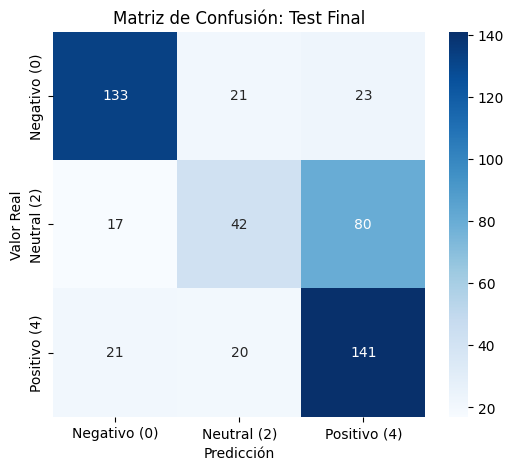

In [2]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Verificar si existe la columna target
if 'target' in df_test.columns:
    print("--- REPORTE TEST FINAL ---")
    print(classification_report(df_test['target'], df_test['target_pred']))

    # 2. Matriz de confusión
    cm = confusion_matrix(df_test['target'], df_test['target_pred'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo (0)', 'Neutral (2)', 'Positivo (4)'],
                yticklabels=['Negativo (0)', 'Neutral (2)', 'Positivo (4)'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión: Test Final')
    plt.show()
else:
    print("El dataset de test no contiene etiquetas reales ('target').")

El modelo a pesar de ser entrenado con un dataset con dos etiquetas, fue capaz de predecir los tweets neutros a traves de predicciones con incertidumbre.
Con un accuracy de 63% el modelo tiene una tendencia a clasificar tweets neutrales como positivos.